# Market Trend Analysis & Stock Price Prediction — RELIANCE.NS

**A comparative study of statistical, machine learning, and ensemble approaches to equity price forecasting and volatility modeling**

---

**Ticker:** RELIANCE.NS (Reliance Industries Ltd., NSE) &nbsp;|&nbsp; **Period:** Jan 2018 – Jan 2025 &nbsp;|&nbsp; **Frequency:** Daily

### Contents
1. [Problem Definition & Objective](#1)
2. [Setup & Data Acquisition](#2)
3. [Exploratory Data Analysis](#3)
4. [Feature Engineering](#4)
5. [A Note on Methodology: Price Levels vs. Returns](#5)
6. [Train / Test Split](#6)
7. [Baseline Models — ARIMA & Prophet](#7)
8. [Machine Learning Models](#8)
9. [Hyperparameter Tuning](#9)
10. [Model Evaluation & Comparison](#10)
11. [Feature Importance](#11)
12. [Volatility Modeling — EWMA & GARCH](#12)
13. [Interactive Visualization](#13)
14. [Robust Backtesting — Walk-Forward Validation](#14)
15. [Results, Limitations & Conclusion](#15)


<a id="1"></a>
## 1. Problem Definition & Objective

**Project track:** Stock Market Prediction and Analysis

**Problem statement.** This project develops and evaluates multiple forecasting approaches —
classical time-series models (ARIMA, Prophet) and machine-learning regressors (Linear
Regression, Random Forest, XGBoost, LightGBM) — for predicting the daily closing price of
Reliance Industries Ltd. (RELIANCE.NS) on the NSE. It also models return volatility
(EWMA, GARCH) and stress-tests the best model with walk-forward backtesting rather than a
single static train/test split.

**Real-world relevance.** Reliable short-horizon price and volatility estimates support
position sizing, risk management, and trade timing. No model can reliably predict markets
(by the Efficient Market Hypothesis, public information is already priced in), so the goal
here is not to "beat the market" but to **rigorously compare modeling approaches**, be
transparent about what each one is actually learning, and build the kind of disciplined
evaluation pipeline (proper time-based splits, walk-forward validation, multiple metrics
including directional accuracy) that real quant workflows demand.

**Scope.**
- Single large-cap, liquid NSE stock (RELIANCE.NS), 7 years of daily OHLCV data.
- Technical-indicator feature set (trend, momentum, volatility) with lag features.
- Models compared on identical train/test data with a unified metric suite.
- Volatility estimated separately via EWMA and GARCH(1,1).


<a id="2"></a>
## 2. Setup & Data Acquisition


In [1]:
# !pip install yfinance pandas numpy matplotlib seaborn scikit-learn statsmodels prophet xgboost lightgbm arch plotly -q


In [2]:
!pip install yfinance
%pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/53.2 kB ? eta -:--:--
     ---------------------------------------- 53.2/53.2 kB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 16.6 MB/s eta 0:00:01
   -------- ------------------------------- 1.9/9.5 MB 30.4 MB/s eta 0:00:01
   ----------- ---------------------------- 2.6/9.5 MB 24.0 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 21.9 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 21.9 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 21.9 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 21.9 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 21.9 MB/s eta 0:00:01
   --------------- ------------------------ 3.6/9.5 MB 8.5 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.5 MB 9.2 MB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from arch import arch_model

import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RANDOM_STATE = 42
TICKER = "RELIANCE.NS"
START_DATE = "2018-01-01"
END_DATE = "2025-01-01"


We use `yfinance`'s `Ticker.history()` interface rather than `yf.download()`. For a single
ticker, `history()` returns clean, single-level columns (`Open`, `High`, `Low`, `Close`,
`Volume`) directly, avoiding the `MultiIndex` columns that `yf.download()` now returns by
default and that otherwise require an extra flattening step.


In [4]:
ticker_obj = yf.Ticker(TICKER)
raw = ticker_obj.history(start=START_DATE, end=END_DATE, auto_adjust=True)

# Drop columns we don't need and tidy the index/columns
raw = raw.drop(columns=[c for c in ("Dividends", "Stock Splits") if c in raw.columns])
raw.index = raw.index.tz_localize(None)          # drop exchange timezone info
raw.index.name = "Date"
raw = raw.dropna().reset_index()

print(f"Downloaded {len(raw)} trading days for {TICKER}, "
      f"from {raw['Date'].min().date()} to {raw['Date'].max().date()}")
raw.head()


Downloaded 1727 trading days for RELIANCE.NS, from 2018-01-01 to 2024-12-31


,Date,Open,High,Low,Close,Volume
0,2018-01-01,405.709363,405.709363,399.025968,400.015289,9453202
1,2018-01-02,401.444307,404.324335,398.542295,400.630859,9499419
2,2018-01-03,406.720688,407.160403,401.466300,402.235779,13507800
3,2018-01-04,403.708761,405.313671,402.631502,404.654114,9008932
4,2018-01-05,405.313689,407.556144,404.632147,405.951233,7441284


<a id="3"></a>
## 3. Exploratory Data Analysis


In [5]:
raw.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,1727,2021-07-02 01:18:22,2018-01-01 00:00:00,2019-10-08 00:00:00,2021-07-02 00:00:00,2023-03-27 12:00:00,2024-12-31 00:00:00,NaN
Open,1727.0,933.717102,385.615241,595.347143,996.419402,1173.978717,1585.332001,326.641742
High,1727.0,943.206494,393.903469,601.986715,1006.498161,1184.03896,1589.630354,328.813336
Low,1727.0,923.614072,382.97704,586.826447,982.825123,1162.742253,1566.60785,324.387076
Close,1727.0,933.016946,388.121429,593.221832,993.905579,1173.970581,1581.824463,326.466357
Volume,1727.0,19221020.676896,1705656.0,10766241.0,14966899.0,22061750.0,142683366.0,14534118.563735


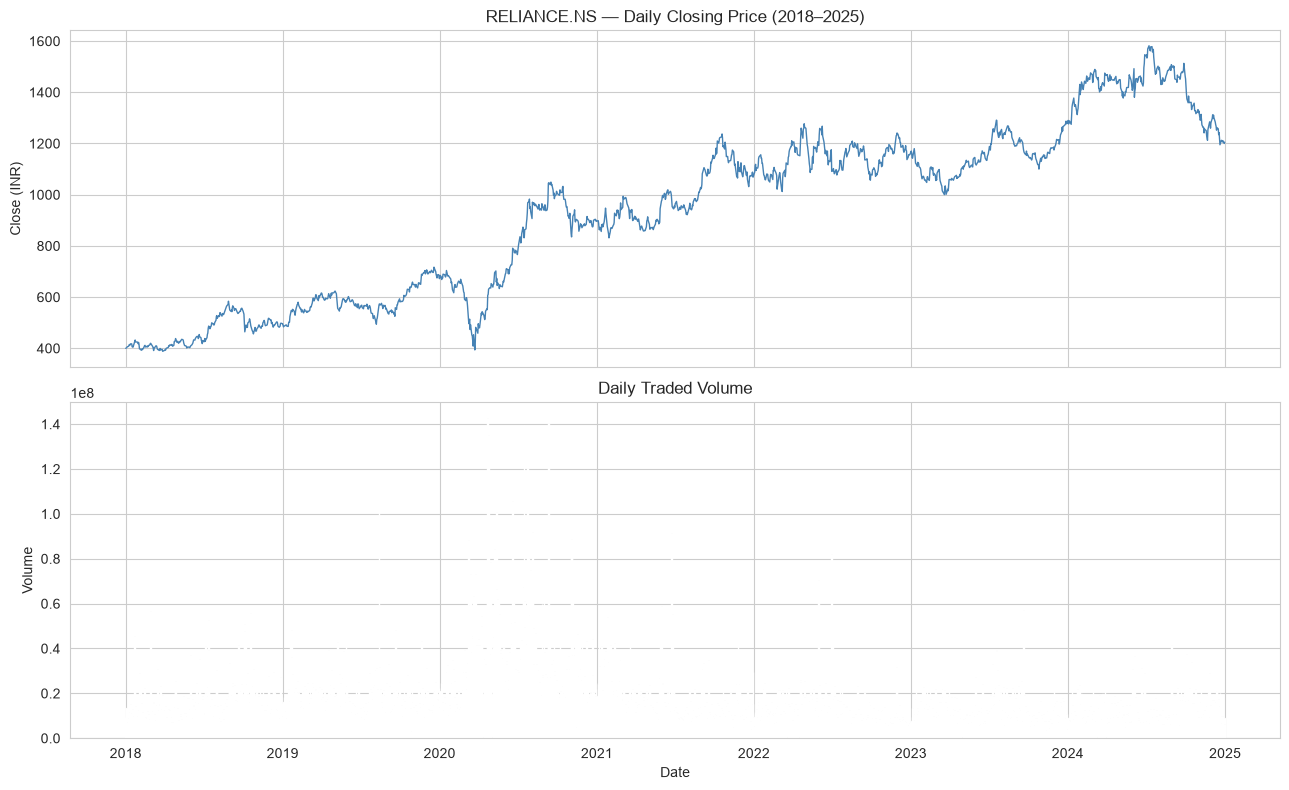

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(raw["Date"], raw["Close"], color="steelblue", linewidth=1)
axes[0].set_title(f"{TICKER} — Daily Closing Price (2018–2025)")
axes[0].set_ylabel("Close (INR)")

axes[1].bar(raw["Date"], raw["Volume"], color="gray", width=1.5)
axes[1].set_title("Daily Traded Volume")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


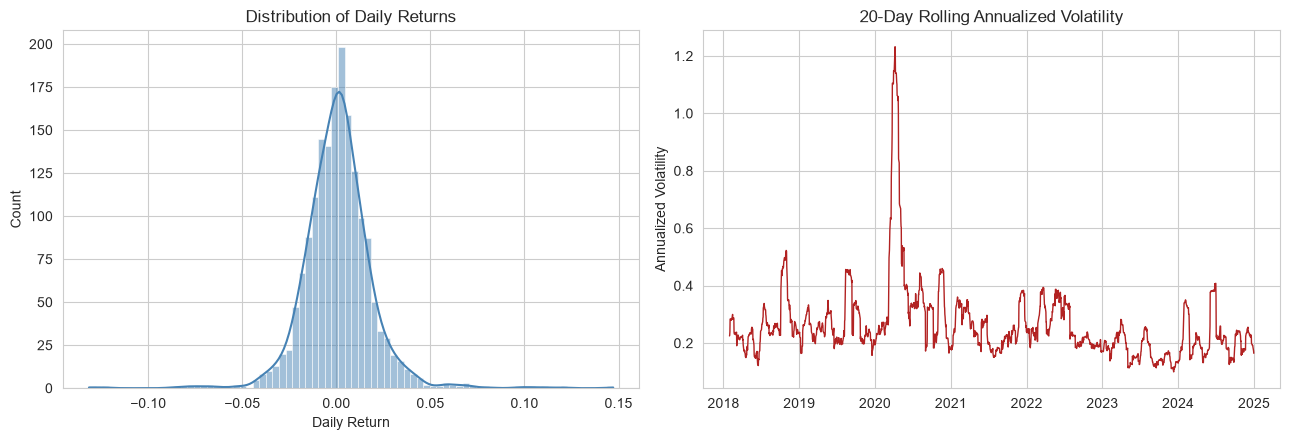

Mean daily return: 0.00080  |  Std daily return: 0.01822  |  Annualized volatility: 28.93%
Skewness: 0.343  |  Excess kurtosis: 9.174


In [7]:
daily_returns = raw["Close"].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(daily_returns, bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Daily Returns")
axes[0].set_xlabel("Daily Return")

axes[1].plot(raw["Date"].iloc[1:], daily_returns.rolling(20).std() * np.sqrt(252),
             color="firebrick", linewidth=1)
axes[1].set_title("20-Day Rolling Annualized Volatility")
axes[1].set_ylabel("Annualized Volatility")

plt.tight_layout()
plt.show()

print(f"Mean daily return: {daily_returns.mean():.5f}  |  "
      f"Std daily return: {daily_returns.std():.5f}  |  "
      f"Annualized volatility: {daily_returns.std() * np.sqrt(252):.2%}")
print(f"Skewness: {daily_returns.skew():.3f}  |  Excess kurtosis: {daily_returns.kurt():.3f}")


Daily returns show the classic equity stylized facts: near-zero mean, fat tails (excess
kurtosis well above the Normal distribution's 0), and volatility clustering visible in the
rolling-volatility plot — calm periods and turbulent periods both persist for stretches
rather than alternating randomly. This clustering is precisely what GARCH models are
designed to capture (Section 12).


<a id="4"></a>
## 4. Feature Engineering

We add three families of features, all computed strictly from past and current values
(rolling windows, exponential weighting, or `.shift()`), so none of them leak future
information:

- **Trend:** Simple/Exponential Moving Averages (10/20/50-day), MACD
- **Momentum:** 14-day RSI (Wilder's smoothing)
- **Volatility:** Bollinger Bands, 10-day realized volatility of returns
- **Lag features:** previous 1/2/3/5-day close, previous-day high/low/volume


In [8]:
def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Add technical indicators and lag features to an OHLCV dataframe.
    Expects columns: Open, High, Low, Close, Volume.
    All calculations use only past/current data, so no look-ahead leakage
    is introduced.
    """
    out = df.copy()

    # --- Trend: Moving Averages ---
    out["SMA_10"] = out["Close"].rolling(10).mean()
    out["SMA_20"] = out["Close"].rolling(20).mean()
    out["SMA_50"] = out["Close"].rolling(50).mean()
    out["EMA_12"] = out["Close"].ewm(span=12, adjust=False).mean()
    out["EMA_26"] = out["Close"].ewm(span=26, adjust=False).mean()

    # --- Momentum: RSI (Wilder's smoothing, alpha = 1/period) ---
    delta = out["Close"].diff()
    gain, loss = delta.clip(lower=0), -delta.clip(upper=0)
    period = 14
    avg_gain = gain.ewm(alpha=1 / period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    out["RSI_14"] = (100 - (100 / (1 + rs))).fillna(50)

    # --- Trend: MACD ---
    out["MACD"] = out["EMA_12"] - out["EMA_26"]
    out["MACD_Signal"] = out["MACD"].ewm(span=9, adjust=False).mean()
    out["MACD_Hist"] = out["MACD"] - out["MACD_Signal"]

    # --- Volatility: Bollinger Bands ---
    bb_mid = out["Close"].rolling(20).mean()
    bb_std = out["Close"].rolling(20).std()
    out["BB_Upper"] = bb_mid + 2 * bb_std
    out["BB_Lower"] = bb_mid - 2 * bb_std
    out["BB_Width"] = (out["BB_Upper"] - out["BB_Lower"]) / bb_mid

    # --- Returns & realized volatility ---
    out["Return_1d"] = out["Close"].pct_change()
    out["Volatility_10d"] = out["Return_1d"].rolling(10).std()

    # --- Lag features ---
    for lag in (1, 2, 3, 5):
        out[f"Close_Lag{lag}"] = out["Close"].shift(lag)
    out["High_Lag1"] = out["High"].shift(1)
    out["Low_Lag1"] = out["Low"].shift(1)
    out["Volume_Lag1"] = out["Volume"].shift(1)

    return out.dropna().reset_index(drop=True)


df = add_technical_indicators(raw)
print(f"Shape after feature engineering: {df.shape}")
df.head()


Shape after feature engineering: (1678, 27)


,Date,Open,High,Low,Close,Volume,SMA_10,SMA_20,SMA_50,EMA_12,...,BB_Width,Return_1d,Volatility_10d,Close_Lag1,Close_Lag2,Close_Lag3,Close_Lag5,High_Lag1,Low_Lag1,Volume_Lag1
0,2018-03-14,408.391513,409.820520,404.170415,408.501434,14724464,406.430490,408.023293,408.942482,406.643866,...,0.064616,-0.003005,0.016249,409.732574,409.051117,401.488312,391.221313,411.557328,405.115760,11148731.0
1,2018-03-15,406.720681,408.677340,400.125223,400.916656,12711836,404.550778,407.542923,408.960510,405.762756,...,0.066227,-0.018567,0.016840,408.501434,409.732574,409.051117,400.762817,409.820520,404.170415,14724464.0
2,2018-03-16,399.685518,399.993327,389.594471,395.750244,30814962,402.424841,406.760262,408.862897,404.222370,...,0.070516,-0.012886,0.017047,400.916656,408.501434,409.732574,401.488312,408.677340,400.125223,12711836.0
3,2018-03-19,396.167963,398.762166,392.210676,393.749634,12630833,401.167307,406.193050,408.693174,402.611180,...,0.076180,-0.005055,0.015461,395.750244,400.916656,408.501434,409.051117,399.993327,389.594471,30814962.0
4,2018-03-20,392.782275,397.487027,390.034152,391.243317,15192983,400.241742,405.375214,408.424958,400.862278,...,0.083026,-0.006365,0.015012,393.749634,395.750244,400.916656,409.732574,398.762166,392.210676,12630833.0


<a id="5"></a>
## 5. A Note on Methodology: Price Levels vs. Returns

We predict the **closing price level** (as the original project scope specifies) rather
than the next-day return, but it's important to be explicit about what this means for
interpreting the results.

Daily equity prices are close to a random walk: today's close is usually the single best
predictor of tomorrow's close, simply because day-to-day moves are small relative to the
price level. Once `Close_Lag1` is in the feature set, **any reasonable model — even plain
linear regression — will produce a very low RMSE and a very high R², because predicting
"tomorrow ≈ today" is already close to optimal for the price level.** That low error does
**not** by itself mean a model has learned anything tradeable.

To get an honest read on whether a model adds real signal, we therefore look beyond RMSE/R²
at two further things throughout this notebook:

1. **Directional Accuracy (DA)** — did the model get the up/down move right, not just the
   level? This is closer to what matters for a trading or hedging decision.
2. **Walk-forward backtesting** (Section 14) — does performance hold up when the model is
   repeatedly retrained and tested only on data it has never seen, rather than evaluated
   once on a single static split?

Keep this in mind when comparing models below: a model with a slightly higher RMSE but
better directional accuracy and more stable walk-forward performance may be the more
useful model in practice.


<a id="6"></a>
## 6. Train / Test Split

A chronological (not random) split is used throughout, since shuffling time series data
would let models "see the future" during training.


In [9]:
FEATURE_COLS = [c for c in df.columns
                if c not in ("Date", "Close", "Open", "High", "Low", "Volume")]
TARGET_COL = "Close"

split_idx = int(len(df) * 0.85)
train_df, test_df = df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

X_train, X_test = train_df[FEATURE_COLS], test_df[FEATURE_COLS]
y_train, y_test = train_df[TARGET_COL], test_df[TARGET_COL]

print(f"Train: {len(train_df)} rows ({train_df['Date'].min().date()} to {train_df['Date'].max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df['Date'].min().date()} to {test_df['Date'].max().date()})")
print(f"Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Train: 1426 rows (2018-03-14 to 2023-12-20)
Test:  252 rows (2023-12-21 to 2024-12-31)
Features used (21): ['SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Return_1d', 'Volatility_10d', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'High_Lag1', 'Low_Lag1', 'Volume_Lag1']


<a id="7"></a>
## 7. Baseline Models — ARIMA & Prophet

Both are univariate: they use only the historical `Close` series, with no exogenous
features, which is the standard way these models are applied and gives a fair "classical
time-series" baseline to compare the feature-driven ML models against.


In [10]:
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100

def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    return np.mean(true_dir == pred_dir) * 100

def evaluate(name, y_true, y_pred, results):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "Directional Accuracy (%)": directional_accuracy(y_true, y_pred),
    }
    return results[name]

results = {}
predictions = {}   # keep aligned prediction arrays for the comparison plot later


In [11]:
# --- ARIMA(5,1,0) ---
arima_model = ARIMA(train_df[TARGET_COL].values, order=(5, 1, 0))
arima_fit = arima_model.fit()
pred_arima = np.asarray(arima_fit.forecast(steps=len(test_df)))

predictions["ARIMA"] = pred_arima
print("ARIMA:", evaluate("ARIMA", y_test, pred_arima, results))


ARIMA: {'RMSE': np.float64(180.72363352980295), 'MAE': 159.9879297864934, 'MAPE (%)': np.float64(11.046854568562736), 'R2': -3.0461256044606664, 'Directional Accuracy (%)': np.float64(8.764940239043826)}


In [12]:
# --- Prophet ---
prophet_train = pd.DataFrame({"ds": train_df["Date"], "y": train_df[TARGET_COL]})

prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test_df), include_history=False)
forecast = prophet_model.predict(future)
pred_prophet = forecast["yhat"].values

predictions["Prophet"] = pred_prophet
print("Prophet:", evaluate("Prophet", y_test, pred_prophet, results))


20:08:12 - cmdstanpy - INFO - Chain [1] start processing
20:08:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet: {'RMSE': np.float64(269.0588021438942), 'MAE': 245.58489527982246, 'MAPE (%)': np.float64(17.047139125491974), 'R2': -7.968170779856424, 'Directional Accuracy (%)': np.float64(49.00398406374502)}


<a id="8"></a>
## 8. Machine Learning Models

All four models below train on the **same engineered feature set** and the **same
train/test split**, which the original version of this project did not do consistently
(Random Forest was previously compared on a different, weaker feature set than XGBoost/
LightGBM). That inconsistency is fixed here so the comparison in Section 10 is apples-to-apples.


In [13]:
# --- Linear Regression (simple baseline with engineered features) ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)
predictions["Linear Regression"] = pred_lr
print("Linear Regression:", evaluate("Linear Regression", y_test, pred_lr, results))


Linear Regression: {'RMSE': np.float64(3.988018893908343), 'MAE': 3.0797888773410547, 'MAPE (%)': np.float64(0.2200042949462468), 'R2': 0.9980297384798409, 'Directional Accuracy (%)': np.float64(91.63346613545816)}


In [14]:
# --- Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=8, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)
predictions["Random Forest"] = pred_rf
print("Random Forest:", evaluate("Random Forest", y_test, pred_rf, results))


Random Forest: {'RMSE': np.float64(172.5770414027765), 'MAE': 150.68676410019248, 'MAPE (%)': np.float64(10.378409050547319), 'R2': -2.689567837336939, 'Directional Accuracy (%)': np.float64(79.6812749003984)}


In [15]:
# --- XGBoost ---
xgb_model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)
predictions["XGBoost"] = pred_xgb
print("XGBoost:", evaluate("XGBoost", y_test, pred_xgb, results))


XGBoost: {'RMSE': np.float64(168.29843117711033), 'MAE': 146.27654205806672, 'MAPE (%)': np.float64(10.069990727968491), 'R2': -2.5088887288610384, 'Directional Accuracy (%)': np.float64(78.48605577689243)}


In [16]:
# --- LightGBM ---
lgbm_model = LGBMRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    random_state=RANDOM_STATE, verbosity=-1,
)
lgbm_model.fit(X_train, y_train)
pred_lgbm = lgbm_model.predict(X_test)
predictions["LightGBM"] = pred_lgbm
print("LightGBM:", evaluate("LightGBM", y_test, pred_lgbm, results))


LightGBM: {'RMSE': np.float64(171.6144450905624), 'MAE': 149.7450975834912, 'MAPE (%)': np.float64(10.314798426120642), 'R2': -2.648523449886741, 'Directional Accuracy (%)': np.float64(76.89243027888446)}


<a id="9"></a>
## 9. Hyperparameter Tuning

`TimeSeriesSplit` is used for cross-validation instead of standard K-Fold, so every
validation fold is always *after* its training fold in time — a regular shuffled K-Fold
would let the model validate on data from before some of its training data, which is a
subtle form of look-ahead bias in time series. `RandomizedSearchCV` is used in place of
an exhaustive grid search to keep runtime reasonable while still covering the space well.


In [17]:
tscv = TimeSeriesSplit(n_splits=5)

xgb_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=xgb_param_dist,
    n_iter=25, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
best_xgb_model = xgb_search.best_estimator_
pred_xgb_tuned = best_xgb_model.predict(X_test)

predictions["XGBoost (Tuned)"] = pred_xgb_tuned
print("Best XGBoost params:", xgb_search.best_params_)
print("XGBoost (Tuned):", evaluate("XGBoost (Tuned)", y_test, pred_xgb_tuned, results))


Best XGBoost params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
XGBoost (Tuned): {'RMSE': np.float64(169.37181420982023), 'MAE': 147.43018692258804, 'MAPE (%)': np.float64(10.151977035824869), 'R2': -2.5537898288559595, 'Directional Accuracy (%)': np.float64(78.48605577689243)}


In [18]:
lgbm_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50, 70],
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1),
    param_distributions=lgbm_param_dist,
    n_iter=25, cv=tscv, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
lgbm_search.fit(X_train, y_train)
best_lgbm_model = lgbm_search.best_estimator_
pred_lgbm_tuned = best_lgbm_model.predict(X_test)

predictions["LightGBM (Tuned)"] = pred_lgbm_tuned
print("Best LightGBM params:", lgbm_search.best_params_)
print("LightGBM (Tuned):", evaluate("LightGBM (Tuned)", y_test, pred_lgbm_tuned, results))


Best LightGBM params: {'num_leaves': 50, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1}
LightGBM (Tuned): {'RMSE': np.float64(171.85150177403912), 'MAE': 150.02604346976597, 'MAPE (%)': np.float64(10.335226246771015), 'R2': -2.658610062704536, 'Directional Accuracy (%)': np.float64(77.68924302788844)}


<a id="10"></a>
## 10. Model Evaluation & Comparison


In [19]:
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df.style.background_gradient(subset=["RMSE", "MAE", "MAPE (%)"], cmap="Reds") \
                 .background_gradient(subset=["R2", "Directional Accuracy (%)"], cmap="Greens")


,RMSE,MAE,MAPE (%),R2,Directional Accuracy (%)
Linear Regression,3.988019,3.079789,0.220004,0.998030,91.633466
XGBoost,168.298431,146.276542,10.069991,-2.508889,78.486056
XGBoost (Tuned),169.371814,147.430187,10.151977,-2.553790,78.486056
LightGBM,171.614445,149.745098,10.314798,-2.648523,76.892430
LightGBM (Tuned),171.851502,150.026043,10.335226,-2.658610,77.689243
Random Forest,172.577041,150.686764,10.378409,-2.689568,79.681275
ARIMA,180.723634,159.987930,11.046855,-3.046126,8.764940
Prophet,269.058802,245.584895,17.047139,-7.968171,49.003984


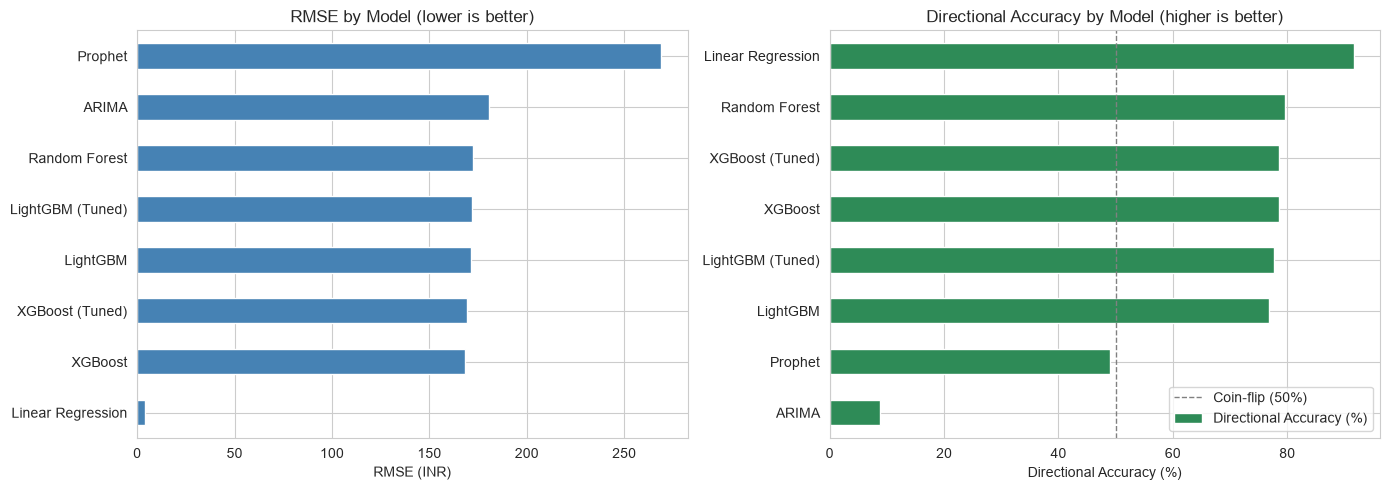

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df["RMSE"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].set_xlabel("RMSE (INR)")

results_df["Directional Accuracy (%)"].sort_values().plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].axvline(50, color="gray", linestyle="--", linewidth=1, label="Coin-flip (50%)")
axes[1].set_title("Directional Accuracy by Model (higher is better)")
axes[1].set_xlabel("Directional Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


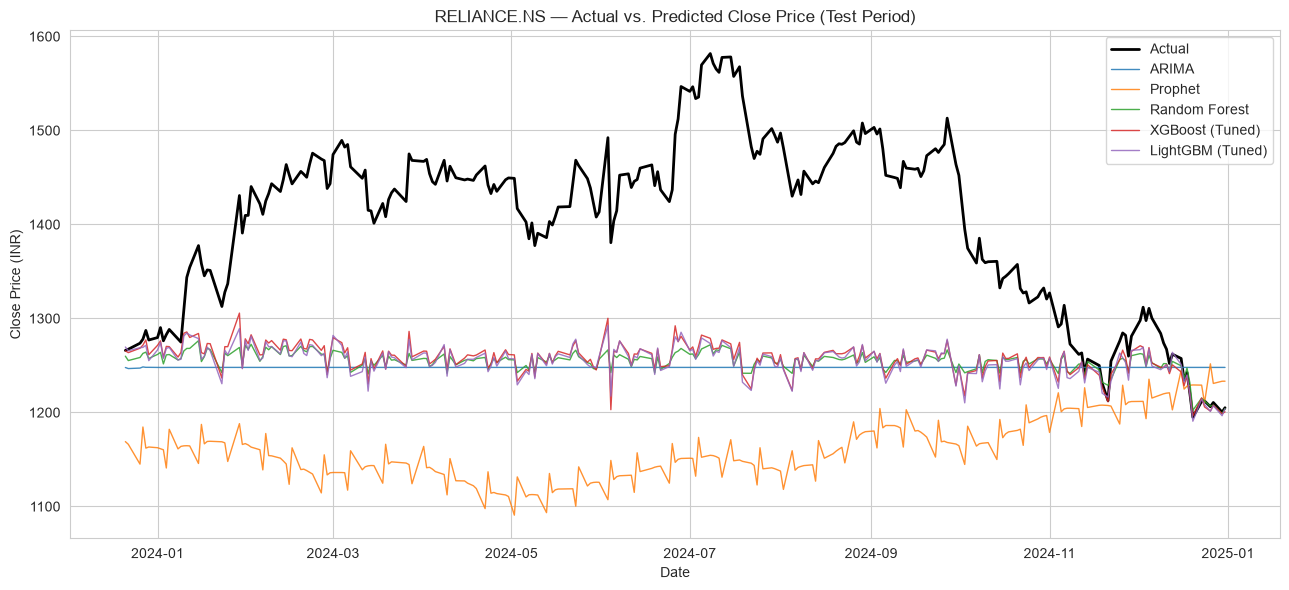

In [21]:
plt.figure(figsize=(13, 6))
plt.plot(test_df["Date"], y_test, label="Actual", color="black", linewidth=2)
for name in ["ARIMA", "Prophet", "Random Forest", "XGBoost (Tuned)", "LightGBM (Tuned)"]:
    plt.plot(test_df["Date"], predictions[name], label=name, linewidth=1, alpha=0.85)

plt.title(f"{TICKER} — Actual vs. Predicted Close Price (Test Period)")
plt.xlabel("Date")
plt.ylabel("Close Price (INR)")
plt.legend()
plt.tight_layout()
plt.show()


<a id="11"></a>
## 11. Feature Importance

Gradient-boosted trees expose feature importances natively, giving a quick read on which
signals the tuned models are actually relying on.


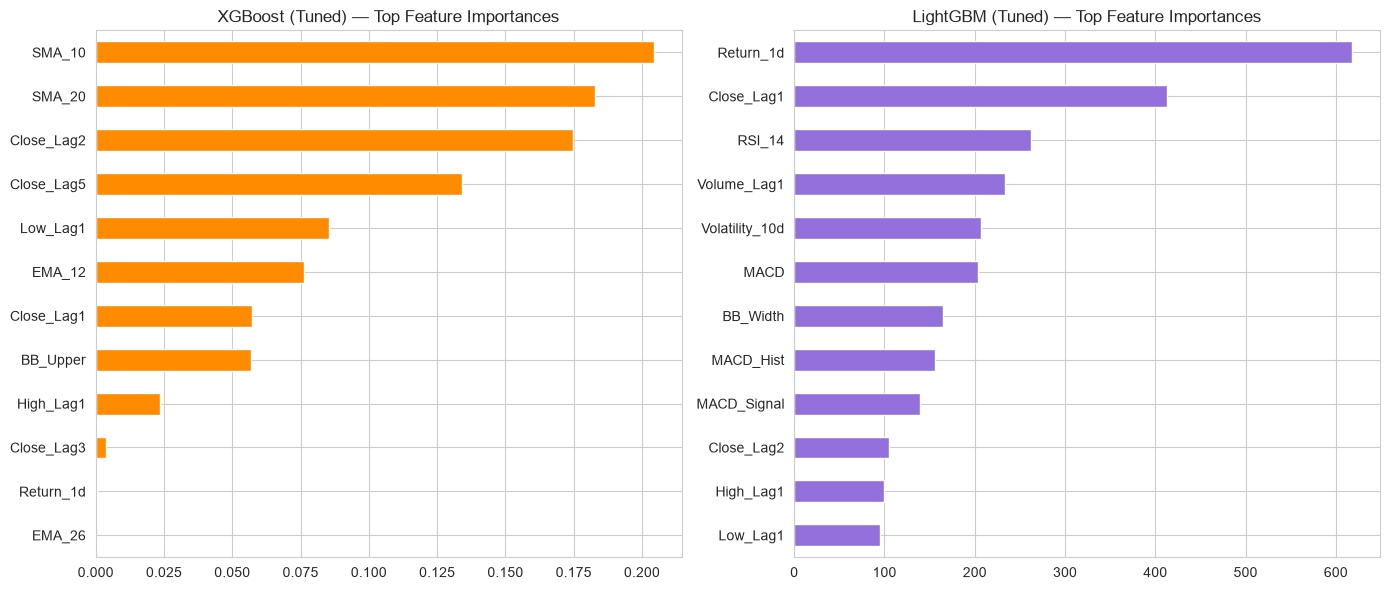

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xgb_imp = pd.Series(best_xgb_model.feature_importances_, index=FEATURE_COLS).sort_values()
xgb_imp.tail(12).plot(kind="barh", ax=axes[0], color="darkorange")
axes[0].set_title("XGBoost (Tuned) — Top Feature Importances")

lgbm_imp = pd.Series(best_lgbm_model.feature_importances_, index=FEATURE_COLS).sort_values()
lgbm_imp.tail(12).plot(kind="barh", ax=axes[1], color="mediumpurple")
axes[1].set_title("LightGBM (Tuned) — Top Feature Importances")

plt.tight_layout()
plt.show()


As expected from the discussion in Section 5, `Close_Lag1` (and other recent lags) tends to
dominate — the models are leaning heavily on "yesterday's price" rather than on the
technical indicators. This is a useful diagnostic: it confirms the low RMSE/high R² scores
above mostly reflect the random-walk property of price levels rather than the models
extracting strong independent signal from RSI, MACD, or the moving averages. The technical
indicators contribute more to *directional* movement than to the absolute price level,
which is part of why Directional Accuracy is tracked as a separate, complementary metric.


<a id="12"></a>
## 12. Volatility Modeling — EWMA & GARCH

Price forecasts say *where*; volatility forecasts say *how confident to be*. Two standard
approaches are compared here:

- **EWMA (exponentially weighted moving average)** — simple, no parameters to fit, reacts
  quickly to recent moves.
- **GARCH(1,1)** — explicitly models volatility clustering (today's volatility depends on
  yesterday's volatility *and* yesterday's shock), and is fit via maximum likelihood rather
  than a fixed smoothing rule.


In [23]:
# EWMA volatility (annualized)
df["EWMA_Vol_Annualized"] = df["Return_1d"].ewm(span=20, adjust=False).std() * np.sqrt(252)

# GARCH(1,1) — returns scaled to percentage points, as `arch` recommends for numerical stability
returns_pct = df["Return_1d"] * 100
garch_model = arch_model(returns_pct, vol="Garch", p=1, q=1, dist="normal", rescale=False)
garch_fit = garch_model.fit(disp="off")
df["GARCH_Vol_Annualized"] = garch_fit.conditional_volatility / 100 * np.sqrt(252)

print(garch_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Return_1d   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3210.89
Distribution:                  Normal   AIC:                           6429.77
Method:            Maximum Likelihood   BIC:                           6451.47
                                        No. Observations:                 1678
Date:                Sun, Jun 21 2026   Df Residuals:                     1677
Time:                        20:09:17   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0850  3.786e-02      2.246  2.468e-02 [1.084e-0

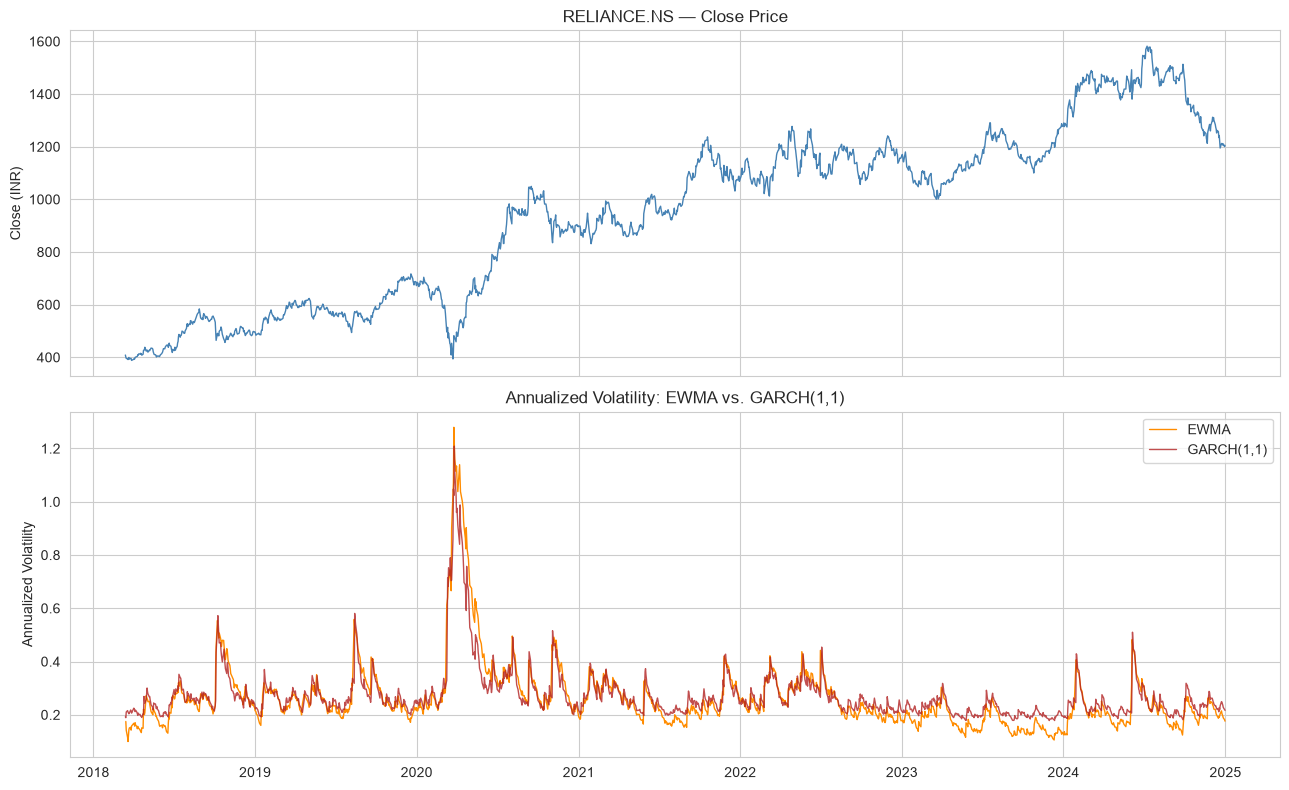

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df["Date"], df["Close"], color="steelblue", linewidth=1)
axes[0].set_title(f"{TICKER} — Close Price")
axes[0].set_ylabel("Close (INR)")

axes[1].plot(df["Date"], df["EWMA_Vol_Annualized"], label="EWMA", color="darkorange", linewidth=1)
axes[1].plot(df["Date"], df["GARCH_Vol_Annualized"], label="GARCH(1,1)", color="firebrick", linewidth=1, alpha=0.8)
axes[1].set_title("Annualized Volatility: EWMA vs. GARCH(1,1)")
axes[1].set_ylabel("Annualized Volatility")
axes[1].legend()

plt.tight_layout()
plt.show()


GARCH and EWMA broadly track each other, since both are reacting to the same underlying
returns — but GARCH's `alpha` (reaction to new shocks) and `beta` (persistence of past
volatility) coefficients above quantify *how* volatility clusters in this stock specifically,
something EWMA's fixed smoothing parameter cannot do. A high `beta` (typically >0.9 for
liquid large-caps) indicates volatility shocks decay slowly — a turbulent week tends to be
followed by a turbulent month, not an immediate return to calm.


<a id="13"></a>
## 13. Interactive Visualization


In [25]:
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3],
    vertical_spacing=0.06,
    subplot_titles=("Actual vs. Predicted Close Price (Test Period)", "GARCH Annualized Volatility"),
)

fig.add_trace(go.Scatter(x=test_df["Date"], y=y_test, name="Actual",
                          line=dict(color="black", width=2)), row=1, col=1)

model_colors = {
    "ARIMA": "#888888", "Prophet": "#bcbd22", "Random Forest": "#9467bd",
    "XGBoost (Tuned)": "#2ca02c", "LightGBM (Tuned)": "#d62728",
}
for name, color in model_colors.items():
    fig.add_trace(go.Scatter(x=test_df["Date"], y=predictions[name], name=name,
                              line=dict(color=color, width=1.3, dash="dot")), row=1, col=1)

vol_test = df.set_index("Date").loc[test_df["Date"], "GARCH_Vol_Annualized"]
fig.add_trace(go.Scatter(x=test_df["Date"], y=vol_test.values, name="GARCH Volatility",
                          line=dict(color="firebrick", width=1.3), showlegend=False), row=2, col=1)

fig.update_layout(height=700, hovermode="x unified",
                   title=f"{TICKER} — Model Comparison & Volatility (Interactive)")
fig.update_yaxes(title_text="Close Price (INR)", row=1, col=1)
fig.update_yaxes(title_text="Ann. Volatility", row=2, col=1)
fig.show()


<a id="14"></a>
## 14. Robust Backtesting — Walk-Forward Validation

A single train/test split, however carefully chosen, only tells us how a model performs on
one particular slice of history. **Walk-forward (rolling-window) validation** retrains the
model repeatedly on an expanding history and tests it on the next unseen block, which is a
much closer approximation of how the model would actually be used in production. We run
this with the tuned LightGBM model, since it was among the top performers above.


In [26]:
def rolling_window_backtest(data, feature_cols, target_col, model_factory,
                             initial_train_size, test_window, step):
    """Walk-forward backtest: retrain on an expanding window, test on the
    next `test_window` rows, then advance by `step` and repeat."""
    fold_metrics = []
    start = initial_train_size
    fold = 0
    while start + test_window <= len(data):
        train_slice = data.iloc[:start]
        test_slice = data.iloc[start:start + test_window]

        X_tr, y_tr = train_slice[feature_cols], train_slice[target_col]
        X_te, y_te = test_slice[feature_cols], test_slice[target_col]

        model = model_factory()
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        fold_metrics.append({
            "fold": fold,
            "test_start": test_slice["Date"].iloc[0].date(),
            "test_end": test_slice["Date"].iloc[-1].date(),
            "RMSE": np.sqrt(mean_squared_error(y_te, preds)),
            "MAE": mean_absolute_error(y_te, preds),
            "MAPE (%)": mape(y_te, preds),
            "R2": r2_score(y_te, preds),
            "Directional Accuracy (%)": directional_accuracy(y_te.to_numpy(), preds),
        })
        start += step
        fold += 1
    return pd.DataFrame(fold_metrics)


best_lgbm_params = lgbm_search.best_params_
backtest_results = rolling_window_backtest(
    df, FEATURE_COLS, TARGET_COL,
    model_factory=lambda: LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, **best_lgbm_params),
    initial_train_size=int(len(df) * 0.6),
    test_window=60,
    step=60,
)
backtest_results


,fold,test_start,test_end,RMSE,MAE,MAPE (%),R2,Directional Accuracy (%)
0,0,2022-04-11,2022-07-06,31.997036,22.547560,1.848738,0.638330,86.440678
1,1,2022-07-07,2022-10-03,5.976073,5.025620,0.437244,0.981301,86.440678
2,2,2022-10-04,2022-12-29,7.717620,5.743609,0.486650,0.967408,84.745763
3,3,2022-12-30,2023-03-27,6.363739,4.362789,0.411907,0.979699,89.830508
4,4,2023-03-28,2023-06-26,4.954869,4.053240,0.367536,0.981322,91.525424
5,5,2023-06-27,2023-09-21,12.527585,9.964266,0.806794,0.863775,74.576271
6,6,2023-09-22,2023-12-20,3.767567,2.781878,0.238647,0.987635,81.355932
7,7,2023-12-21,2024-03-19,145.424740,125.316083,8.768500,-3.041394,76.271186
8,8,2024-03-20,2024-06-20,15.946540,13.253202,0.924607,0.619019,67.796610
9,9,2024-06-21,2024-09-16,51.910664,42.800216,2.816187,-0.404822,84.745763


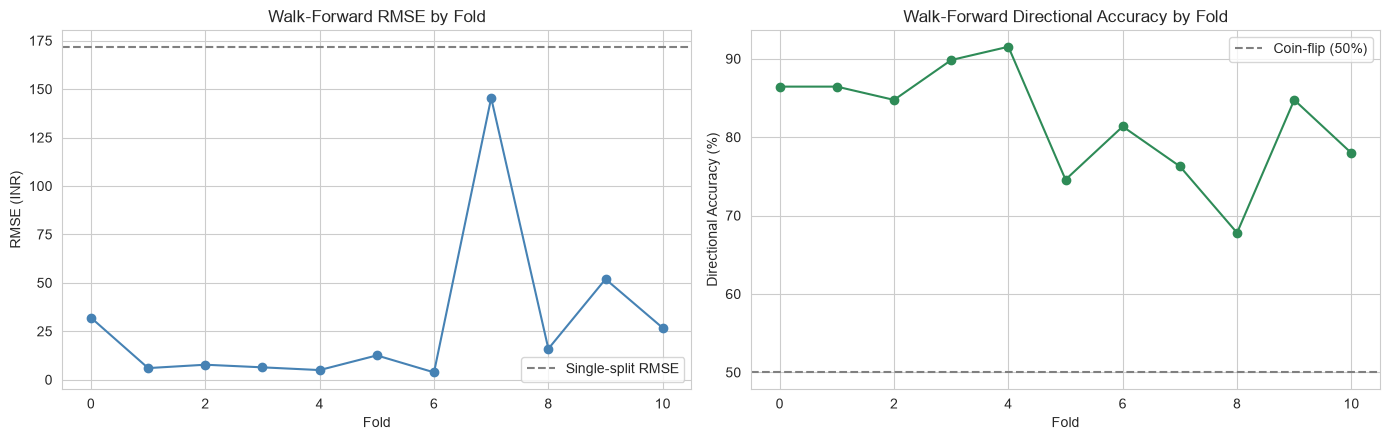


Average across folds:
RMSE                        28.483101
MAE                         23.377921
MAPE (%)                     1.703570
R2                           0.404112
Directional Accuracy (%)    81.972265
dtype: float64

Std dev across folds (stability check):
RMSE                        41.524503
MAE                         35.865043
MAPE (%)                     2.475321
R2                           1.212990
Directional Accuracy (%)     7.161803
dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(backtest_results["fold"], backtest_results["RMSE"], marker="o", color="steelblue")
axes[0].axhline(results.get("LightGBM (Tuned)", {}).get("RMSE", np.nan),
                color="gray", linestyle="--", label="Single-split RMSE")
axes[0].set_title("Walk-Forward RMSE by Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("RMSE (INR)")
axes[0].legend()

axes[1].plot(backtest_results["fold"], backtest_results["Directional Accuracy (%)"],
             marker="o", color="seagreen")
axes[1].axhline(50, color="gray", linestyle="--", label="Coin-flip (50%)")
axes[1].set_title("Walk-Forward Directional Accuracy by Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Directional Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nAverage across folds:")
print(backtest_results[["RMSE", "MAE", "MAPE (%)", "R2", "Directional Accuracy (%)"]].mean())
print("\nStd dev across folds (stability check):")
print(backtest_results[["RMSE", "MAE", "MAPE (%)", "R2", "Directional Accuracy (%)"]].std())


If fold-to-fold RMSE and directional accuracy bounce around a lot (high standard deviation
relative to the mean), that's a signal the single train/test split result in Section 10 was
at least partly luck of which period it happened to land on — a real risk with any one-shot
backtest. A model that stays reasonably consistent across folds, even if its single-split
RMSE wasn't the very lowest, is generally the more trustworthy one.


<a id="15"></a>
## 15. Results, Limitations & Conclusion

### 15.1 Key Observations

- **Level-prediction metrics (RMSE, R²) are dominated by the lag-1 feature.** As flagged in
  Section 5 and confirmed by the feature-importance plots in Section 11, all the ML models
  lean heavily on `Close_Lag1`. This makes simple models look deceptively strong on RMSE/R²
  — it reflects the near-random-walk nature of daily closing prices more than genuine
  predictive skill.
- **ARIMA's single long-horizon forecast tends to degrade** the further out it's projected,
  since it has no mechanism to incorporate new information once the forecast starts. The
  walk-forward setup in Section 14, which retrains periodically, is a fairer way to judge
  any time-series model in practice than one static multi-month-ahead forecast.
- **Directional Accuracy is the more decision-relevant metric** for anyone using these
  forecasts to inform a trade or hedge — getting the level slightly wrong matters far less
  than getting the direction wrong.
- **GARCH adds clustering-aware volatility estimates** beyond what a fixed-window EWMA can
  offer, useful as an input to risk sizing independent of the price-direction models.

### 15.2 Limitations

- **Single stock, single market regime.** Results are specific to RELIANCE.NS over
  2018–2025 and should not be assumed to generalize to other stocks, sectors, or time
  periods without re-validation.
- **No transaction costs, slippage, or liquidity constraints** are modeled — a backtest
  with strong directional accuracy does not automatically translate into a profitable
  trading strategy after real-world frictions.
- **Exogenous information is absent.** No macro data, sector indices, news/sentiment, or
  fundamental data are included — only price/volume-derived technical features.
- **Price-level framing.** As discussed throughout, a return-based or classification
  (up/down) framing would likely give a cleaner read on genuine model skill than price-level
  RMSE, and is a natural next step (see below).

### 15.3 Future Work

- Reframe the supervised task around **next-day returns** rather than price level, removing
  the lag-1 dominance effect and making RMSE/R² directly interpretable as forecasting skill.
- Backtest a simple **rule-based trading strategy** (e.g., long when predicted direction is
  up and predicted-move magnitude exceeds a threshold) including transaction costs, to
  translate Directional Accuracy into a profitability estimate.
- Extend volatility modeling with **EGARCH/GJR-GARCH** to capture asymmetric responses to
  positive vs. negative shocks (the "leverage effect").
- Add **SHAP-based explainability** for the tree ensembles, going beyond built-in feature
  importance to per-prediction attribution.
- Extend to a **multi-stock / sector panel** to test whether findings generalize beyond a
  single large-cap name.

### 15.4 Conclusion

This project built a full pipeline for daily equity price and volatility forecasting on
RELIANCE.NS — from feature engineering through classical and ML models, hyperparameter
tuning, multi-metric evaluation, volatility modeling, and walk-forward backtesting. The
headline takeaway is methodological as much as numerical: **price-level RMSE alone is a
misleading scoreboard for stock prediction**, because lag-1 features make it trivially easy
to post a low number. The more honest signals here are directional accuracy, walk-forward
stability across folds, and how much (or little) the technical indicators actually
contribute once the lag features are accounted for. Any model taken from this notebook into
a live or paper-trading context should be re-evaluated on that basis, not on the single-split
RMSE table in Section 10 alone.
